In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_rows = []
with open('data/SampleSuperstore.csv', 'r') as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(',')]
    while parts and parts[-1] == '': parts.pop()
    if len(parts) >= 8:
        try:
            # Standard order: Sales(-4), Qty(-3), Disc(-2), Profit(-1)
            metrics = [float(p) for p in parts[-4:]] 
            data_rows.append({
                'Region': parts[-7], 'Category': parts[-6], 'Sub-Category': parts[-5],
                'Sales': metrics[0], 'Quantity': metrics[1], 'Discount': metrics[2], 'Profit': metrics[3]
            })
        except: continue

df = pd.DataFrame(data_rows)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [3]:
plt.figure(figsize=(22, 14), dpi=100)
sns.set_style("whitegrid")

<Figure size 2200x1400 with 0 Axes>

C:\Users\Testing\AppData\Local\Temp\ipykernel_17240\43519253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='Sales', palette='Set3', showfliers=False)


Text(0.5, 1.0, '1. Regional Sales Distribution (Focus on Core 95%)')

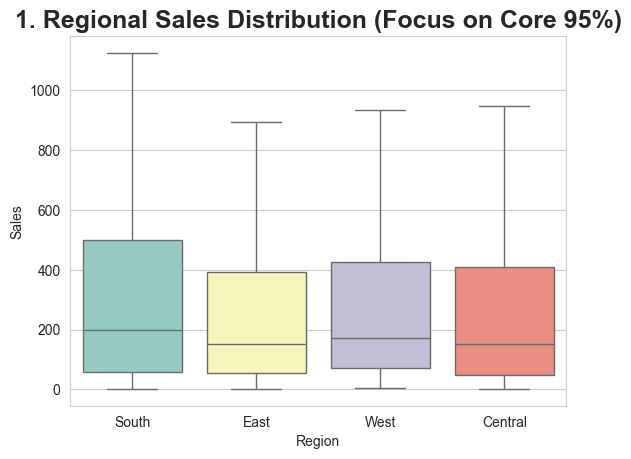

In [5]:
plt.subplot(1,1, 1)
sns.boxplot(data=df, x='Region', y='Sales', palette='Set3', showfliers=False)
plt.title('1. Regional Sales Distribution (Focus on Core 95%)', fontsize=18, fontweight='bold')

C:\Users\Testing\AppData\Local\Temp\ipykernel_17240\2790477671.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_summary.sort_values('Profit_Margin'), x='Category', y='Profit_Margin', palette='RdYlGn')


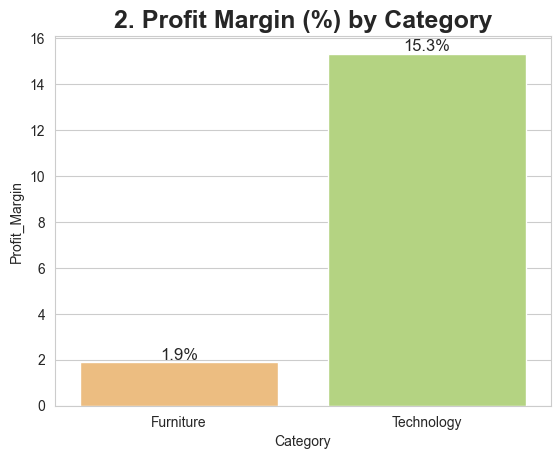

In [ ]:
plt.subplot(1,1,1)
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat_summary['Profit_Margin'] = (cat_summary['Profit'] / cat_summary['Sales']) * 100
ax = sns.barplot(data=cat_summary.sort_values('Profit_Margin'), x='Category', y='Profit_Margin', palette='RdYlGn')
plt.title('2. Profit Margin (%) by Category', fontsize=18, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)

Text(0.5, 1.0, '3. Discount Impact on Profitability')

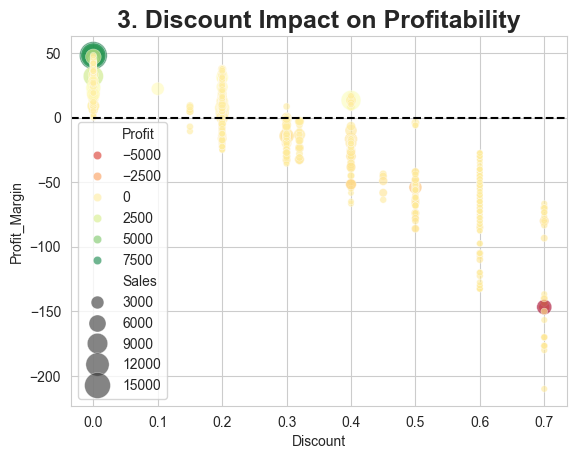

In [8]:
plt.subplot(1,1,1)
sns.scatterplot(data=df, x='Discount', y='Profit_Margin', size='Sales', hue='Profit', palette='RdYlGn', alpha=0.6, sizes=(20, 400))
plt.axhline(0, color='black', linestyle='--')
plt.title('3. Discount Impact on Profitability', fontsize=18, fontweight='bold')

C:\Users\Testing\AppData\Local\Temp\ipykernel_17240\3693119870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sales', y='Sub-Category', estimator=np.mean, order=sub_order, palette='viridis')


Text(0.5, 1.0, '4. Mean Sales per Sub-Category (Log-Scale Visibility)')

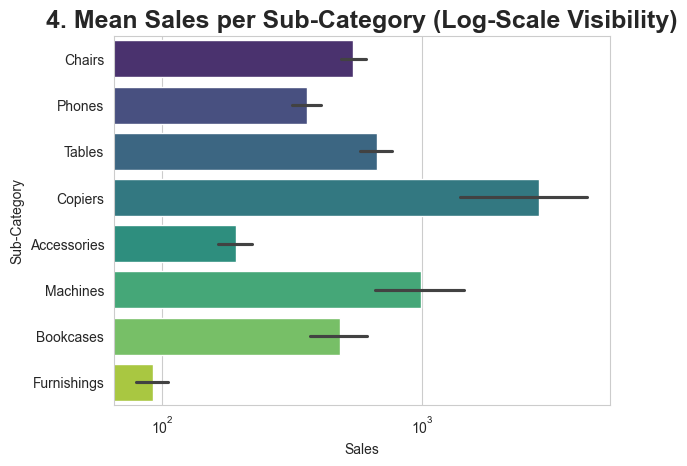

In [ ]:
plt.subplot(1,1,1)
sub_order = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).index
sns.barplot(data=df, x='Sales', y='Sub-Category', estimator=np.mean, order=sub_order, palette='viridis')
plt.xscale('log')
plt.title('4. Mean Sales per Sub-Category (Log-Scale Visibility)', fontsize=18, fontweight='bold')

In [10]:
plt.tight_layout(pad=5.0)
plt.savefig('capstone_dashboard_final.png')
plt.show()

<Figure size 640x480 with 0 Axes>